In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 38.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 22.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 36.7 MB/s eta 0:00:00


In [30]:
import numpy as np # used for handling numbers
import pandas as pd # used for handling the dataset
from sklearn.impute import SimpleImputer # used for handling missing data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # used for encoding categorical data
from sklearn.model_selection import train_test_split # used for splitting training and testing data
from sklearn.preprocessing import StandardScaler # used for feature scaling

In [31]:
import pandas as pd
input = pd.read_csv('/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/preprocessedInput.csv', encoding='utf-8')

In [32]:
input.head()

,episode,speakers,utterances,emotions,cleaned_utterances,hindi_utterances,english_utterances
0,roseshantstobeadopted.wmv,maya,kya kya bhar ke rakha hai indravadan ne is gha...,disgust,kya kya bhar ke rakha hai indravadan ne ghar m...,क्य क्य भर् के रख है इन्द्रवदन् ने इस् घर् मेइ...,What does Indravadan keep in the house? Indrav...
1,roseshantstobeadopted.wmv,indu,"ok, chalo rosesh chalo bahar",contempt,ok chalo rosesh chalo bahar,"ओक्, चलो रोसेश् चलो बहर्","ok, let's rise, let's spring"
2,roseshantstobeadopted.wmv,rosesh,momma! hath chhodiye dad!,anger,momma hath chhodiye dad,मोम्म! हथ् छोदिये दद्!,Momma! Hath Chodiye Dad!
3,roseshantstobeadopted.wmv,indu,dekho maya ya na bol raha hai! fir tum hi kaho...,neutral,dekho maya ya na bol raha hai fir tum hi kahog...,देखो मय य न बोल् रह है! फ़िर् तुम् हि कहोगि फ़ल्...,Look Maya or I am not speaking! Then you will ...
4,roseshantstobeadopted.wmv,maya,"indravadan, tum kitne salo se ye joke maar rah...",neutral,indravadan tum kitne salo se ye joke maar rahe...,"इन्द्रवदन्, तुम् कित्ने सलो से ये जोके मार् रह...","Indravadan, for how many years have you been t..."


In [33]:
input['utterance_id'] = range(1, len(input) + 1)
input

,episode,speakers,utterances,emotions,cleaned_utterances,hindi_utterances,english_utterances,utterance_id
0,roseshantstobeadopted.wmv,maya,kya kya bhar ke rakha hai indravadan ne is gha...,disgust,kya kya bhar ke rakha hai indravadan ne ghar m...,क्य क्य भर् के रख है इन्द्रवदन् ने इस् घर् मेइ...,What does Indravadan keep in the house? Indrav...,1
1,roseshantstobeadopted.wmv,indu,"ok, chalo rosesh chalo bahar",contempt,ok chalo rosesh chalo bahar,"ओक्, चलो रोसेश् चलो बहर्","ok, let's rise, let's spring",2
2,roseshantstobeadopted.wmv,rosesh,momma! hath chhodiye dad!,anger,momma hath chhodiye dad,मोम्म! हथ् छोदिये दद्!,Momma! Hath Chodiye Dad!,3
3,roseshantstobeadopted.wmv,indu,dekho maya ya na bol raha hai! fir tum hi kaho...,neutral,dekho maya ya na bol raha hai fir tum hi kahog...,देखो मय य न बोल् रह है! फ़िर् तुम् हि कहोगि फ़ल्...,Look Maya or I am not speaking! Then you will ...,4
4,roseshantstobeadopted.wmv,maya,"indravadan, tum kitne salo se ye joke maar rah...",neutral,indravadan tum kitne salo se ye joke maar rahe...,"इन्द्रवदन्, तुम् कित्ने सलो से ये जोके मार् रह...","Indravadan, for how many years have you been t...",5
...,...,...,...,...,...,...,...,...
8501,radhabaileaves,rosesh,lekin what about my ghadi? 17000 ki ghadi hai ...,sadness,lekin ghadi ki ghadi hai momma recurring alarm...,लेकिन् व्हत् अबोउत् म्य् घदि? १७००० कि घदि है ...,but what about my Ghadi? 17000 ki ghadi hai mo...,8502
8502,radhabaileaves,sita or geeta,"nhi nhi mujhe yahan pe kaamich nhi karna hai, ...",anger,nhi nhi mujhe yahan pe kaamich nhi karna hai j...,"न्हि न्हि मुझे यहन् पे कामिच् न्हि कर्न है, मे...","No no, I don't want to do evil here, I am here!",8503
8503,radhabaileaves,maya,ahan!,joy,ahan,अहन्!,oh!,8504
8504,radhabaileaves,sita or geeta,goodbye!,fear,goodbye,गूद्ब्ये!,goodbye!,8505


In [34]:
train = input[['utterance_id', 'hindi_utterances', 'emotions']]
train

,utterance_id,hindi_utterances,emotions
0,1,क्य क्य भर् के रख है इन्द्रवदन् ने इस् घर् मेइ...,disgust
1,2,"ओक्, चलो रोसेश् चलो बहर्",contempt
2,3,मोम्म! हथ् छोदिये दद्!,anger
3,4,देखो मय य न बोल् रह है! फ़िर् तुम् हि कहोगि फ़ल्...,neutral
4,5,"इन्द्रवदन्, तुम् कित्ने सलो से ये जोके मार् रह...",neutral
...,...,...,...
8501,8502,लेकिन् व्हत् अबोउत् म्य् घदि? १७००० कि घदि है ...,sadness
8502,8503,"न्हि न्हि मुझे यहन् पे कामिच् न्हि कर्न है, मे...",anger
8503,8504,अहन्!,joy
8504,8505,गूद्ब्ये!,fear


<Axes: >

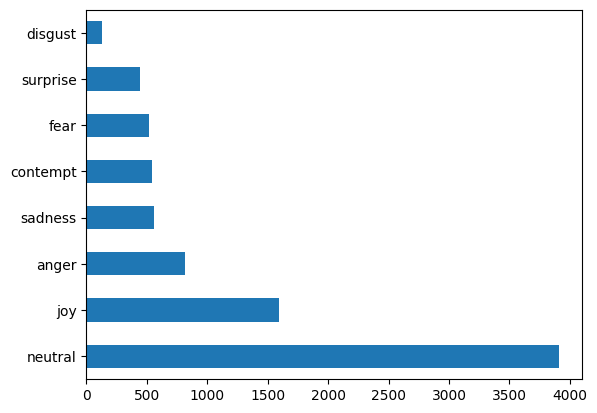

In [35]:
train['emotions'].value_counts().plot(kind="barh")

In [36]:
train.isnull().sum().sum()

0

In [37]:
emotion_mapping = {
    'neutral': 0,
    'joy': 1,
    'anger': 2,
    'sadness': 3,
    'contempt': 4,
    'fear': 5,
    'surprise': 6,
    'disgust': 7
}

train['emotions'] = train['emotions'].map(emotion_mapping)
train

<ipython-input-37-795c3443588f>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['emotions'] = train['emotions'].map(emotion_mapping)


,utterance_id,hindi_utterances,emotions
0,1,क्य क्य भर् के रख है इन्द्रवदन् ने इस् घर् मेइ...,7
1,2,"ओक्, चलो रोसेश् चलो बहर्",4
2,3,मोम्म! हथ् छोदिये दद्!,2
3,4,देखो मय य न बोल् रह है! फ़िर् तुम् हि कहोगि फ़ल्...,0
4,5,"इन्द्रवदन्, तुम् कित्ने सलो से ये जोके मार् रह...",0
...,...,...,...
8501,8502,लेकिन् व्हत् अबोउत् म्य् घदि? १७००० कि घदि है ...,3
8502,8503,"न्हि न्हि मुझे यहन् पे कामिच् न्हि कर्न है, मे...",2
8503,8504,अहन्!,1
8504,8505,गूद्ब्ये!,5


In [90]:
import torch
import transformers
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertForSequenceClassification.from_pretrained("bert-base-multilingual-cased", num_labels=8, problem_type="multi_label_classification")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [91]:
train.emotions.unique()

array([7, 4, 2, 0, 1, 3, 5, 6])

In [92]:
sentences = train.hindi_utterances.values
labels = train.emotions.values
print(len(sentences), len(labels))

8506 8506


In [93]:
import tqdm as tqdm
import torch

In [94]:
res = max(train['hindi_utterances'], key = len)
len(res)
res = sum(map(len, train['hindi_utterances']))/float(len(train['hindi_utterances']))
c=0
for i in train['hindi_utterances']:
    if len(i)<100:
        c=c+1
c

7189

In [95]:
# Tokenize all of the sentences and map the tokens to thier word IDs.
input_ids = []
attention_masks = []

# For every sentence...
for sent in tqdm.tqdm(sentences):
    # `encode_plus` will:
    #   (1) Tokenize the sentence.
    #   (2) Prepend the `[CLS]` token to the start.
    #   (3) Append the `[SEP]` token to the end.
    #   (4) Map tokens to their IDs.
    #   (5) Pad or truncate the sentence to `max_length`
    #   (6) Create attention masks for [PAD] tokens.
    encoded_dict = tokenizer.encode_plus(
                        sent,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length =100 ,           # Pad & truncate all sentences.
                        pad_to_max_length = True,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                        truncation=True
                   )

    # Add the encoded sentence to the list.
    input_ids.append(encoded_dict['input_ids'])

    # And its attention mask (simply differentiates padding from non-padding).
    attention_masks.append(encoded_dict['attention_mask'])

# Convert the lists into tensors.
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)

# Print sentence 0, now as a list of IDs.
print('Original: ', sentences[0])
print('Token IDs:', input_ids[0])

100%|██████████| 8506/8506 [00:03<00:00, 2187.72it/s]

Original:  क्य क्य भर् के रख है इन्द्रवदन् ने इस् घर् मेइन् इन्द्रवदन् प्लेअसे तुम् सरि बेकर् कि चिजेन् बहर् क्योन् नहिन् फ़ेक्ते?
Token IDs: tensor([   101,    865,  14251,    865,  14251, 103733,  20429,  10412,    891,
         27841,  10569,  30114,  60254,  18321,  15070,  49978,  20429,  13088,
         14265,  20429,  58016,  20429,  40265,  50275,  20429,  30114,  60254,
         18321,  15070,  49978,  20429,    885,  50101,  11554, 111192,  35622,
           880,  14070,  45753,    898,  11549,  12878,    887,  53809,  11549,
         20429,  14117,    870,  12878,  77285,  41013,    887,  49050,  20429,
           865,  49036,  41013,    884,  17110,  25936,  20429,    886,  35773,
         53809,  29161,  11554,    136,    102,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,    

In [96]:
model.resize_token_embeddings(len(tokenizer))

Embedding(119547, 768, padding_idx=0)

In [97]:
labels.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7])

In [98]:
from torch.utils.data import TensorDataset, random_split

# Combine the training inputs into a TensorDataset.
dataset = TensorDataset(input_ids, attention_masks, labels)

# Calculate the number of samples to include in each set.
train_size = int(len(dataset))

print('{:>5,} training samples'.format(train_size))

8,506 training samples


In [99]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# The DataLoader needs to know our batch size for training, so we specify it
# here. For fine-tuning BERT on a specific task, the authors recommend a batch
# size of 16 or 32.
batch_size = 8
# Create the DataLoaders for our training and validation sets.
# We'll take training samples in random order.
train_dataloader = DataLoader(
            dataset,  # The training samples.
            # sampler = RandomSampler(train_dataset), # Select batches randomly
            batch_size = batch_size # Trains with this batch size.
        )

In [100]:
from transformers import AdamW
optimizer = AdamW(model.parameters(),
                  lr = 1e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                )

In [101]:
from transformers import get_linear_schedule_with_warmup

# Number of training epochs. The BERT authors recommend between 2 and 4.
# We chose to run for 4, but we'll see later that this may be over-fitting the
# training data.
epochs = 5
# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

In [102]:
import numpy as np

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [103]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4


In [104]:
import datetime
torch.cuda.empty_cache()

In [105]:
model.cuda()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [106]:
import os

# Saving best-practices: if you use defaults names for the model, you can reload it using from_pretrained()

output_dir = '/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/Final_Predictions'

# Create output directory if needed
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Saving model to %s" % output_dir)

Saving model to /content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/Final_Predictions


In [107]:
import torch.nn as nn

# Create the loss function
criterion = nn.CrossEntropyLoss()

In [108]:
import random
import numpy as np
import time
# This training code is based on the `run_glue.py` script here:
# https://github.com/huggingface/transformers/blob/5bfcd0485ece086ebcbed2d008813037968a9e58/examples/run_glue.py#L128

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

# We'll store a number of quantities such as training and validation loss,
# validation accuracy, and timings.
training_stats = []

# Measure the total training time for the whole run.
total_t0 = time.time()

# For each epoch...
for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_train_loss = 0
    total_eval_accuracy=0

    # Put the model into training mode. Don't be mislead--the call to
    # `train` just changes the *mode*, it doesn't *perform* the training.
    # `dropout` and `batchnorm` layers behave differently during training
    # vs. test (source: https://stackoverflow.com/questions/51433378/what-does-model-train-do-in-pytorch)
    model.train()

    # For each batch of training data...
    for step, batch in enumerate(train_dataloader):

        # Progress update every 40 batches.
        if step % 1000 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = time.time() - t0

            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

        # Unpack this training batch from our dataloader.
        #
        # As we unpack the batch, we'll also copy each tensor to the GPU using the
        # `to` method.
        #
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Always clear any previously calculated gradients before performing a
        # backward pass. PyTorch doesn't do this automatically because
        # accumulating the gradients is "convenient while training RNNs".
        # (source: https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch)
        model.zero_grad()

        # Perform a forward pass (evaluate the model on this training batch).
        # The documentation for this `model` function is here:
        # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
        # It returns different numbers of parameters depending on what arguments
        # arge given and what flags are set. For our useage here, it returns
        # the loss (because we provided labels) and the "logits"--the model
        # outputs prior to activation.
        outputs = model(b_input_ids,
                             token_type_ids=None,
                             attention_mask=b_input_mask,
                             labels=b_labels)
         # The call to `model` always returns a tuple, so we need to pull the
        # loss value out of the tuple.
        # loss = outputs[0]
            # Move logits and labels to CPU
        # logits = outputs[1].detach().cpu().numpy()
        logits = outputs.logits
        loss = criterion(logits, b_labels)

        label_ids = b_labels.cpu().numpy()

        # Accumulate the training loss over all of the batches so that we can
        # calculate the average loss at the end. `loss` is a Tensor containing a
        # single value; the `.item()` function just returns the Python value
        # from the tensor.
        total_train_loss += loss.item()
        total_eval_accuracy += flat_accuracy(logits, label_ids)
        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the gradients to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        # The optimizer dictates the "update rule"--how the parameters are
        # modified based on their gradients, the learning rate, etc.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_accuracy = total_eval_accuracy / len(train_dataloader)
    print(avg_train_loss)
    print(avg_train_accuracy)
    # Measure how long this epoch took.
    training_time = time.time() - t0

    print("")
    # print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epcoh took: {:}".format(training_time))
    model_to_save = model.module if hasattr(model, 'module') else model  # Take care of distributed/parallel training
    model_to_save.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)

    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.

    # print("")
    # print("Running Validation...")

    # t0 = time.time()

    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    # model.eval()

    # # Tracking variables
    # total_eval_accuracy = 0
    # total_eval_loss = 0
    # nb_eval_steps = 0

    # Evaluate data for one epoch
    # for batch in validation_dataloader:

    #     # Unpack this training batch from our dataloader.
    #     #
    #     # As we unpack the batch, we'll also copy each tensor to the GPU using
    #     # the `to` method.
    #     #
    #     # `batch` contains three pytorch tensors:
    #     #   [0]: input ids
    #     #   [1]: attention masks
    #     #   [2]: labels
    #     b_input_ids = batch[0].to(device)
    #     b_input_mask = batch[1].to(device)
    #     b_labels = batch[2].to(device)

    #     # Tell pytorch not to bother with constructing the compute graph during
    #     # the forward pass, since this is only needed for backprop (training).
    #     with torch.no_grad():

    #         # Forward pass, calculate logit predictions.
    #         # token_type_ids is the same as the "segment ids", which
    #         # differentiates sentence 1 and 2 in 2-sentence tasks.
    #         # The documentation for this `model` function is here:
    #         # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
    #         # Get the "logits" output by the model. The "logits" are the output
    #         # values prior to applying an activation function like the softmax.
    #         (loss, logits) = model(b_input_ids,
    #                                token_type_ids=None,
    #                                attention_mask=b_input_mask,
    #                                labels=b_labels)

    #     # Accumulate the validation loss.
    #     # total_eval_loss += loss.item()

    #     # Move logits and labels to CPU
    #     logits = logits.detach().cpu().numpy()
    #     label_ids = b_labels.to('cpu').numpy()

    #     # Calculate the accuracy for this batch of test sentences, and
    #     # accumulate it over all batches.
    #     total_eval_accuracy += flat_accuracy(logits, label_ids)


    # # Report the final accuracy for this validation run.
    # avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    # print("  Accuracy: {0:.2f}".format(avg_val_accuracy))

    # # Calculate the average loss over all of the batches.
    # avg_val_loss = total_eval_loss / len(validation_dataloader)

    # # Measure how long the validation run took.
    # validation_time = format_time(time.time() - t0)

    # print("  Validation Loss: {0:.2f}".format(avg_val_loss))
    # print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            # 'Valid. Loss': avg_val_loss,
            'Valid. Accur.': avg_train_accuracy,
            # 'Training Time': training_time,
            # 'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")

# print("Total training took {:} (h:mm:ss)".format(time.time()-total_t0))


======== Epoch 1 / 5 ========
Training...


ValueError: ignored